In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import math
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Epoch 1: Train Loss = 0.1096, Val Loss = 0.1959
Epoch 2: Train Loss = 0.0580, Val Loss = 0.1940
Epoch 3: Train Loss = 0.0515, Val Loss = 0.2157
Epoch 4: Train Loss = 0.0480, Val Loss = 0.2037
Epoch 5: Train Loss = 0.0459, Val Loss = 0.1958
Epoch 6: Train Loss = 0.0430, Val Loss = 0.2021
Evaluation Metrics (Denormalized):
  R² Score: 0.8780
  MAE: 0.7288
  MSE: 0.8318


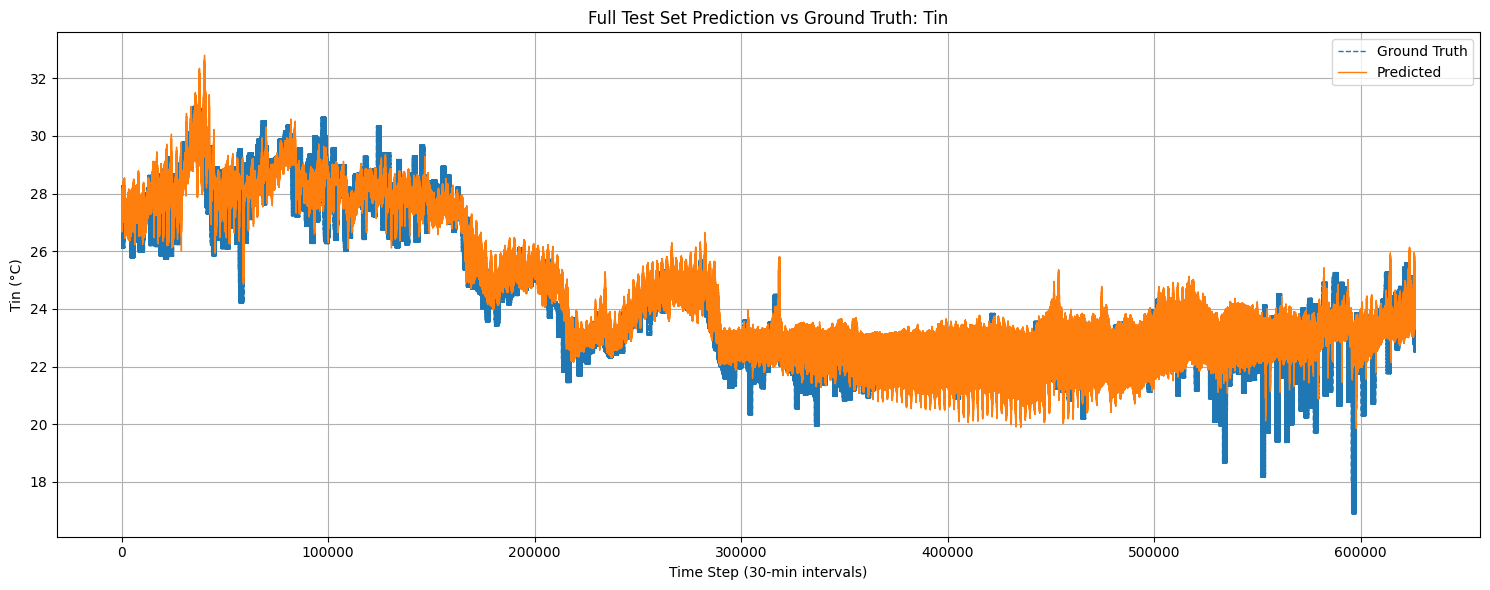

(0.8779562091200264, 0.7288069089116013, 0.8318319073728423)

In [12]:
import os
from meteostat import Hourly, Stations
from datetime import datetime
INPUT_SEQ_LEN = 48 
OUTPUT_SEQ_LEN = 48  
FEATURES = ["Tin", "Tout", "total_energy", 'RH']
TIME_FEATURES = ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

def fetch_weather_data(start, end):
    stations = Stations()
    station = stations.nearby(lat=44.358650539440056, lon=9.72338718772366).fetch(1)
    station_id = station.index[0]

    # start = datetime(2024, 1, 1)
    # end = datetime(2024, 12, 31)

    data = Hourly(station_id, start, end)
    weather = data.fetch()
    weather_30min = weather.resample('30min').interpolate()

    temp_30min = weather_30min[['temp']]

    weather_api_df = temp_30min.rename(columns={
        'time': 'timestamp',
        'temp': 'Tout',
    })
    return weather_api_df


class Seq2SeqIndoorLSTM(nn.Module):
    def __init__(self, input_dim, decoder_input_dim, hidden_size=64, output_seq_len=48):
        super().__init__()
        self.hidden_size = hidden_size
        self.encoder_lstm = nn.LSTM(input_dim, hidden_size,  num_layers=2,  batch_first=True, dropout=0.15)
        self.decoder_lstm = nn.LSTM(decoder_input_dim, hidden_size, num_layers=2,  batch_first=True, dropout=0.15)
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, encoder_inputs, decoder_inputs):
        _, (h, c) = self.encoder_lstm(encoder_inputs)

        decoder_output, _ = self.decoder_lstm(decoder_inputs, (h, c))
        out = self.output_layer(decoder_output).squeeze(-1)
        return out  


def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for xb_enc, xb_dec, yb in train_loader:
            optimizer.zero_grad()
            preds = model(xb_enc, xb_dec)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb_enc, xb_dec, yb in val_loader:
                preds = model(xb_enc, xb_dec)
                val_loss += criterion(preds, yb).item()

        print(f"Epoch {epoch+1}: Train Loss = {total_loss/len(train_loader):.4f}, Val Loss = {val_loss/len(val_loader):.4f}")

def evaluate_model(model, test_loader, scaler, target_variable="Tin"):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb_enc, xb_dec, yb in test_loader:
            preds = model(xb_enc, xb_dec)
            all_preds.append(preds.numpy())
            all_targets.append(yb.numpy())

    preds = np.concatenate(all_preds, axis=0)
    targets = np.concatenate(all_targets, axis=0)

    feature_index = FEATURES.index(target_variable)
    mean_val = scaler.mean_[feature_index]
    std_val = scaler.scale_[feature_index]

    preds_real = preds * std_val + mean_val
    targets_real = targets * std_val + mean_val

    preds_flat = preds_real.flatten()
    targets_flat = targets_real.flatten()

    r2 = r2_score(targets_flat, preds_flat)
    mae = mean_absolute_error(targets_flat, preds_flat)
    mse = mean_squared_error(targets_flat, preds_flat)

    print(f"Evaluation Metrics (Denormalized):")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")

    plt.figure(figsize=(15, 6))
    plt.plot(targets_flat, label="Ground Truth", linestyle='--', linewidth=1)
    plt.plot(preds_flat, label="Predicted", linestyle='-', linewidth=1)
    plt.xlabel("Time Step (30-min intervals)")
    
    y_label = "Tin (°C)" if target_variable == "Tin" else "RH (%)"
    plt.ylabel(y_label)
    plt.title(f"Full Test Set Prediction vs Ground Truth: {target_variable}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    return r2, mae, mse



class MultiHouseDataset(Dataset):
    def __init__(self, house_dfs, house_id_to_index, target_variable="Tin", scaler=None):
        self.house_id_to_index = house_id_to_index
        self.target_variable = target_variable
        self.X, self.decoder_X, self.y = [], [], []

        if scaler is None:
            self.scaler = StandardScaler()
            all_feature_data = np.concatenate([
                df[FEATURES].values for df in house_dfs
            ])
            self.scaler.fit(all_feature_data)
        else:
            self.scaler = scaler

        for df in house_dfs:
            df = df.copy()
            house_id = df['house_id'].iloc[0]
            self.process_house(df, house_id)

        self.X = torch.tensor(np.concatenate(self.X), dtype=torch.float32)
        self.decoder_X = torch.tensor(np.concatenate(self.decoder_X), dtype=torch.float32)
        self.y = torch.tensor(np.concatenate(self.y), dtype=torch.float32)

    def one_hot_house(self, house_index, length):
        vec = np.zeros((length, len(self.house_id_to_index)))
        vec[:, house_index] = 1.0
        return vec

    def process_house(self, df, house_id):
        df['hour'] = df.index.hour + df.index.minute / 60.0
        df['dayofyear'] = df.index.dayofyear
        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        df['doy_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
        df['doy_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)
        # df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')


        df[FEATURES] = self.scaler.transform(df[FEATURES])

        data_feat = df[FEATURES].values
        data_time = df[TIME_FEATURES].values
        target_data = df[self.target_variable].values
        house_index = self.house_id_to_index[house_id]

        for i in range(len(df) - INPUT_SEQ_LEN - OUTPUT_SEQ_LEN):
            enc_x = data_feat[i:i+INPUT_SEQ_LEN]
            enc_time = data_time[i:i+INPUT_SEQ_LEN]
            enc_house = self.one_hot_house(house_index, INPUT_SEQ_LEN)
            enc_seq = np.concatenate([enc_x, enc_time, enc_house], axis=1)

            dec_tout = data_feat[i+INPUT_SEQ_LEN:i+INPUT_SEQ_LEN+OUTPUT_SEQ_LEN, FEATURES.index("Tout")].reshape(-1, 1)
            dec_time = data_time[i+INPUT_SEQ_LEN:i+INPUT_SEQ_LEN+OUTPUT_SEQ_LEN]
            dec_house = self.one_hot_house(house_index, OUTPUT_SEQ_LEN)
            dec_seq = np.concatenate([dec_tout, dec_time, dec_house], axis=1)

            target = target_data[i+INPUT_SEQ_LEN:i+INPUT_SEQ_LEN+OUTPUT_SEQ_LEN]

            self.X.append(enc_seq[np.newaxis, :, :])
            self.decoder_X.append(dec_seq[np.newaxis, :, :])
            self.y.append(target[np.newaxis, :])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.decoder_X[idx], self.y[idx]

file_path = 'datasets/madalena_processed_30min'
house_dfs = [] 
house_files = [f for f in os.listdir(file_path) if f.endswith('.csv') and f != 'E_152.csv']
house_ids = sorted([int(f.split('_')[1].split('.')[0]) for f in house_files])
house_id_to_index = {hid: idx for idx, hid in enumerate(house_ids)}
for file in os.listdir(file_path):
    full_path = os.path.join(file_path, file)
    if file == 'E_152.csv':
        continue
    house_id = int(file.split('_')[1].split('.')[0])
    df = pd.read_csv(full_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    df = df.sort_index()
    df['house_id'] = house_id
    house_dfs.append(df)

total = len(house_dfs)
train_end = int(0.7 * total)
val_end = int(0.85 * total)

train_dfs = house_dfs[:train_end]
val_dfs = house_dfs[train_end:val_end]
test_dfs = house_dfs[val_end:]
 

train_dataset = MultiHouseDataset(train_dfs, house_id_to_index)
val_dataset = MultiHouseDataset(val_dfs, house_id_to_index, scaler=train_dataset.scaler)
test_dataset = MultiHouseDataset(test_dfs, house_id_to_index, scaler=train_dataset.scaler)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

input_dim = train_dataset.X.shape[2]
decoder_input_dim = train_dataset.decoder_X.shape[2]
model = Seq2SeqIndoorLSTM(input_dim, decoder_input_dim)
train_model(model, train_loader, val_loader, epochs=6, lr=0.001)
evaluate_model(model, test_loader, scaler=train_dataset.scaler)


Epoch 1: Train Loss = 0.2279, Val Loss = 0.3381
Epoch 2: Train Loss = 0.1055, Val Loss = 0.3783
Epoch 3: Train Loss = 0.0950, Val Loss = 0.3859
Epoch 4: Train Loss = 0.0871, Val Loss = 0.4005
Epoch 5: Train Loss = 0.0803, Val Loss = 0.3756
Evaluation Metrics (Denormalized):
  R² Score: 0.7899
  MAE: 2.7905
  MSE: 11.9758


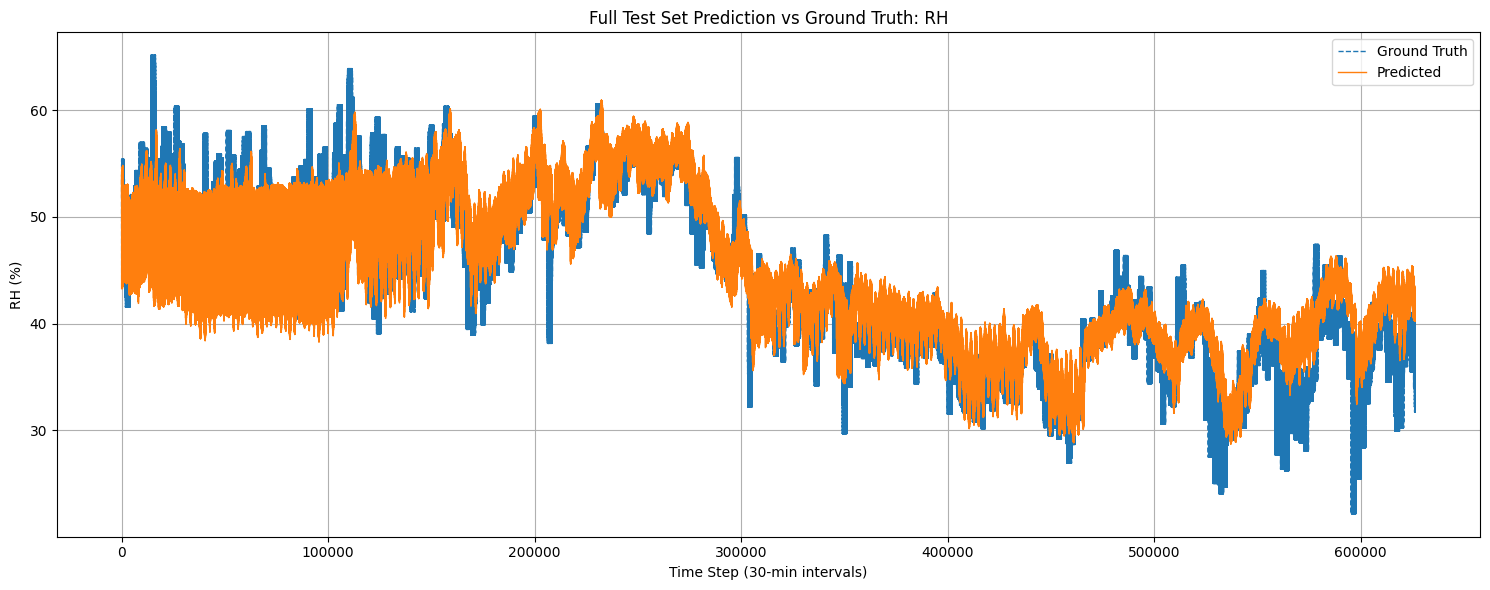

(0.7898926601170028, 2.7904719246039837, 11.975776450606118)

In [13]:
class Seq2SeqRH_LSTM(nn.Module):
    def __init__(self, input_dim, decoder_input_dim, hidden_size=64, num_layers=5, dropout_rate=0.3):
        super().__init__()
        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout_rate,
            batch_first=True
        )
        self.decoder_lstm = nn.LSTM(
            input_size=decoder_input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout_rate,
            batch_first=True
        )
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, encoder_inputs, decoder_inputs):
        _, (h, c) = self.encoder_lstm(encoder_inputs)
        decoder_output, _ = self.decoder_lstm(decoder_inputs, (h, c))
        out = self.output_layer(decoder_output).squeeze(-1)
        return out
    
rh_train_dataset = MultiHouseDataset(train_dfs, house_id_to_index, target_variable="RH")
rh_val_dataset = MultiHouseDataset(val_dfs, house_id_to_index, target_variable="RH", scaler=rh_train_dataset.scaler)
rh_test_dataset = MultiHouseDataset(test_dfs, house_id_to_index, target_variable="RH", scaler=rh_train_dataset.scaler)

rh_train_loader = DataLoader(rh_train_dataset, batch_size=64, shuffle=True)
rh_val_loader = DataLoader(rh_val_dataset, batch_size=64)
rh_test_loader = DataLoader(rh_test_dataset, batch_size=64)

rh_model = Seq2SeqRH_LSTM(
    input_dim=rh_train_dataset.X.shape[2],
    decoder_input_dim=rh_train_dataset.decoder_X.shape[2]
)

train_model(rh_model, rh_train_loader, rh_val_loader, epochs=5, lr=0.0005)
evaluate_model(rh_model, rh_test_loader, scaler=rh_train_dataset.scaler, target_variable="RH")


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import pointbiserialr

file_path = 'datasets/madalena_processed_30min'
house_files = [f for f in os.listdir(file_path) if f.endswith('.csv') and f != 'E_152.csv']
house_ids = sorted([int(f.split('_')[1].split('.')[0]) for f in house_files])
house_id_to_index = {hid: idx for idx, hid in enumerate(house_ids)}
for file in os.listdir(file_path):
    full_path = os.path.join(file_path, file)
    if file == 'E_152.csv':
        continue
    house_id = int(file.split('_')[1].split('.')[0])
    df = pd.read_csv(full_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    df = df.sort_index()
    df['house_id'] = house_id


    df['Tin_lag_1'] = df['Tin'].shift(1).fillna(method='bfill')

    corr_df = df[['heat_pump_active', 'Tin_lag_1', 'Tin', 'RH']]

    corr, p_value = pointbiserialr(corr_df['heat_pump_active'], corr_df['Tin'])

    print(f"Correlation between heat pump active and Tin: {corr:.4f}, p-value: {p_value:.4f}")
    
    corr, p_value = pointbiserialr(corr_df['heat_pump_active'], corr_df['RH'])
    print(f"Correlation between heat pump active and RH: {corr:.4f}, p-value: {p_value:.4f}")

    # plt.figure(figsize=(8, 6))
    # sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    # plt.title('Correlation Heatmap')
    # plt.show()

Correlation between heat pump active and Tin: -0.8818, p-value: 0.0000
Correlation between heat pump active and RH: -0.0692, p-value: 0.0000
Correlation between heat pump active and Tin: -0.0647, p-value: 0.0000
Correlation between heat pump active and RH: -0.3840, p-value: 0.0000
Correlation between heat pump active and Tin: -0.3579, p-value: 0.0000
Correlation between heat pump active and RH: -0.3107, p-value: 0.0000
Correlation between heat pump active and Tin: -0.3335, p-value: 0.0000
Correlation between heat pump active and RH: -0.1496, p-value: 0.0000


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7344\545530704.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Tin_lag_1'] = df['Tin'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7344\545530704.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Tin_lag_1'] = df['Tin'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7344\545530704.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Tin_lag_1'] = df['Tin'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7344\545530704.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Tin_